# Google Colab Lab Assignment -Pretrained Modle

**Course Name:** Deep Learning

**Lab Title:** Research Paper Implementation with Pre-trained Model(Exploring deep residual network based features for automatic schizophrenia detection from EEG)

**Student Name:** Tanashree Koshti

**Student ID:** 202301060024

**Date of Submission:** 19-02-2026

**Group Members**: Saniya Katkar, Srushti Kapse, Kasak Zutshi

**Research Paper Study and Implementation**

**Instructions:**

1. Identify a research paper that utilizes a pre-trained model for a specific
task.

2. Study the methodology, dataset, and model used in the research paper.

3. Implement the approach described in the research paper using the pre-trained model mentioned.

4. Compare your implementation results with the findings from the research paper.


**Objective**
1.   Study a research paper utilizing a pre-trained model.
2.   Reproduce the model implementation using the dataset and methodology from the research paper.
3.   Fine-tune the pre-trained model and optimize hyperparameters.
3.   Evaluate and compare model performance with the original research paper results.









**Task 1: Research Paper Selection and Dataset Preparation (2 hours)**

**Instructions:**

1. Select a research paper that applies a pre-trained model (e.g., VGG, ResNet, EfficientNet, etc.).

2. Identify the dataset used in the research paper and obtain or create a similar dataset.(**https://repod.icm.edu.pl/dataset.xhtml?persistentId=doi:10.18150%2Frepod.0107441&utm**)

3. Perform necessary preprocessing steps:

 Resize images to match the model input dimensions.

 Apply data augmentation techniques if applicable.

4. Split the dataset into training, validation, and testing sets.

In [6]:
from google.colab import files
files.upload()

Saving dataverse_files.zip to dataverse_files.zip


In [7]:
!unzip dataverse_files.zip

Archive:  dataverse_files.zip
   creating: dataverse_files/
  inflating: dataverse_files/h01.edf  
  inflating: dataverse_files/h02.edf  
  inflating: dataverse_files/h03.edf  
  inflating: dataverse_files/h04.edf  
  inflating: dataverse_files/h05.edf  
  inflating: dataverse_files/h06.edf  
  inflating: dataverse_files/h07.edf  
  inflating: dataverse_files/h08.edf  
  inflating: dataverse_files/h09.edf  
  inflating: dataverse_files/h10.edf  
  inflating: dataverse_files/h11.edf  
  inflating: dataverse_files/h12.edf  
  inflating: dataverse_files/h13.edf  
  inflating: dataverse_files/h14.edf  
  inflating: dataverse_files/MANIFEST.TXT  
  inflating: dataverse_files/s01.edf  
  inflating: dataverse_files/s02.edf  
  inflating: dataverse_files/s03.edf  
  inflating: dataverse_files/s04.edf  
  inflating: dataverse_files/s05.edf  
  inflating: dataverse_files/s06.edf  
  inflating: dataverse_files/s07.edf  
  inflating: dataverse_files/s08.edf  
  inflating: dataverse_files/s09.edf  

In [8]:
import os

for root, dirs, files in os.walk("dataverse_files"):
    print("Folder:", root)
    print("Files:", files[:5])
    print("-----")

Folder: dataverse_files
Files: ['s02.edf', 's05.edf', 's14.edf', 'h06.edf', 'h04.edf']
-----


In [9]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 36.4 MB/s eta 0:00:00


In [10]:
import os
import numpy as np
import mne
import matplotlib.pyplot as plt
from scipy import signal
from PIL import Image
from sklearn.model_selection import train_test_split

In [11]:
dataset_path = "dataverse_files"

file_list = [f for f in os.listdir(dataset_path) if f.endswith('.edf')]

print("Total files:", len(file_list))
print(file_list[:5])

Total files: 28
['s02.edf', 's05.edf', 's14.edf', 'h06.edf', 'h04.edf']


In [12]:
images = []
labels = []

for file in file_list:

    file_path = os.path.join(dataset_path, file)

    # Load EEG
    raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
    data = raw.get_data()

    # Take first channel
    eeg_signal = data[0]

    # Generate spectrogram
    frequencies, times, spectrogram = signal.spectrogram(
        eeg_signal, fs=raw.info['sfreq']
    )

    spectrogram = np.log1p(spectrogram)

    # Save spectrogram image temporarily
    plt.figure(figsize=(2,2))
    plt.imshow(spectrogram, aspect='auto', cmap='jet')
    plt.axis('off')
    plt.tight_layout(pad=0)
    plt.savefig("temp.png", bbox_inches='tight', pad_inches=0)
    plt.close()

    # Open and convert to RGB
    img = Image.open("temp.png")
    img = img.resize((224,224))
    img = img.convert("RGB")   # 🔥 THIS FIXES 4 CHANNEL ISSUE

    img_array = np.array(img)

    images.append(img_array)

    # Assign label
    if file.startswith('s'):
        labels.append(1)
    else:
        labels.append(0)

images = np.array(images)
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: (28, 224, 224, 3)
Labels shape: (28,)


In [13]:
images = np.array(images)
labels = np.array(labels)

In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels, test_size=0.3, random_state=42, stratify=labels)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (19, 224, 224, 3)
Validation: (4, 224, 224, 3)
Test: (5, 224, 224, 3)


In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

**Task 2: Model Implementation and Fine-tuning**

**Instructions:**

1. Implement the pre-trained model as described in the research paper.

2. Visualize feature maps of few layers

3. Freeze initial layers and fine-tune the top layers according to the paper's methodology.

4. Optimize hyperparameters such as:

  Learning rate

  Batch size

  Number of epochs

  Optimizer choice (Adam, SGD, RMSprop, etc.)

4. Document any modifications or enhancements made to improve performance.

In [16]:
from tensorflow.keras.applications.resnet50 import preprocess_input

X_train = preprocess_input(X_train.astype('float32'))
X_val = preprocess_input(X_val.astype('float32'))
X_test = preprocess_input(X_test.astype('float32'))

In [17]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [18]:
for layer in base_model.layers[:-20]:  # freeze most layers
    layer.trainable = False

In [19]:
x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [20]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=4
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.7803 - loss: 0.6139 - val_accuracy: 0.7500 - val_loss: 0.4984
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.6446 - loss: 1.1378 - val_accuracy: 0.5000 - val_loss: 2.1943
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5716 - loss: 2.7115 - val_accuracy: 1.0000 - val_loss: 0.2005
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7736 - loss: 1.3353 - val_accuracy: 1.0000 - val_loss: 0.2096
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9094 - loss: 0.1037 - val_accuracy: 0.7500 - val_loss: 0.3884
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.8781 - loss: 0.5521 - val_accuracy: 0.5000 - val_loss: 1.3782
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9302 - loss: 0.1549 - val_accuracy: 1.0000 - val_loss: 0.2686
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8538 - loss: 0.7439 - val_accuracy: 0.7500 - val_loss: 0.3572
Epoch 9/20


In [22]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.2000 - loss: 0.9390
Test Accuracy: 0.20000000298023224


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


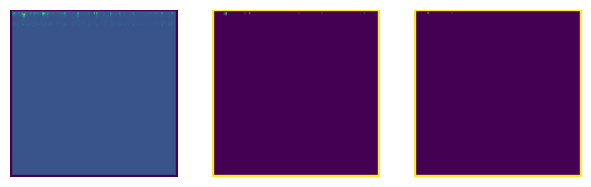

In [23]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

layer_name = base_model.layers[1].name
intermediate_model = Model(
    inputs=model.input,
    outputs=model.get_layer(layer_name).output
)

feature_maps = intermediate_model.predict(X_test[:1])

# Get number of channels dynamically
num_filters = feature_maps.shape[-1]

plt.figure(figsize=(10,10))

for i in range(min(num_filters, 16)):  # limit to 16 max
    plt.subplot(4,4,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap='viridis')
    plt.axis('off')

plt.show()

In [24]:
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
import pandas as pd

learning_rates = [1e-3, 1e-4]
batch_sizes = [4, 8]
epochs_list = [15, 25]
optimizers_list = {
    "adam": Adam,
    "sgd": SGD,
    "rmsprop": RMSprop
}

results = []

for lr in learning_rates:
    for batch_size in batch_sizes:
        for epochs in epochs_list:
            for opt_name, opt_class in optimizers_list.items():

                print(f"\nLR={lr}, Batch={batch_size}, Epochs={epochs}, Optimizer={opt_name}")

                # Re-compile model with new optimizer
                optimizer = opt_class(learning_rate=lr)

                model.compile(
                    optimizer=optimizer,
                    loss='binary_crossentropy',
                    metrics=['accuracy']
                )

                history = model.fit(
                    X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=epochs,
                    batch_size=batch_size,
                    verbose=0
                )

                best_val_acc = max(history.history['val_accuracy'])

                results.append({
                    "Learning Rate": lr,
                    "Batch Size": batch_size,
                    "Epochs": epochs,
                    "Optimizer": opt_name,
                    "Best Val Accuracy": best_val_acc
                })

                print("Best Val Accuracy:", best_val_acc)

# Show sorted results
results_df = pd.DataFrame(results)
print(results_df.sort_values(by="Best Val Accuracy", ascending=False))


LR=0.001, Batch=4, Epochs=15, Optimizer=adam
Best Val Accuracy: 0.5

LR=0.001, Batch=4, Epochs=15, Optimizer=sgd
Best Val Accuracy: 0.75

LR=0.001, Batch=4, Epochs=15, Optimizer=rmsprop
Best Val Accuracy: 1.0

LR=0.001, Batch=4, Epochs=25, Optimizer=adam
Best Val Accuracy: 1.0

LR=0.001, Batch=4, Epochs=25, Optimizer=sgd
Best Val Accuracy: 1.0

LR=0.001, Batch=4, Epochs=25, Optimizer=rmsprop
Best Val Accuracy: 1.0

LR=0.001, Batch=8, Epochs=15, Optimizer=adam
Best Val Accuracy: 1.0

LR=0.001, Batch=8, Epochs=15, Optimizer=sgd
Best Val Accuracy: 1.0

LR=0.001, Batch=8, Epochs=15, Optimizer=rmsprop
Best Val Accuracy: 1.0

LR=0.001, Batch=8, Epochs=25, Optimizer=adam
Best Val Accuracy: 1.0

LR=0.001, Batch=8, Epochs=25, Optimizer=sgd
Best Val Accuracy: 1.0

LR=0.001, Batch=8, Epochs=25, Optimizer=rmsprop
Best Val Accuracy: 1.0

LR=0.0001, Batch=4, Epochs=15, Optimizer=adam
Best Val Accuracy: 1.0

LR=0.0001, Batch=4, Epochs=15, Optimizer=sgd
Best Val Accuracy: 1.0

LR=0.0001, Batch=4, Epo

In [25]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Final Test Accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 914ms/step - accuracy: 0.8000 - loss: 17.9763
Final Test Accuracy: 0.800000011920929


In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = (model.predict(X_test) > 0.5).astype("int32")

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
[[3 0]
 [1 1]]
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      0.50      0.67         2

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5



**Task 3: Model Evaluation and Performance Comparison**

**Instructions:**

1. Evaluate the trained model using performance metrics:

 Accuracy, Precision,Recall, F1-score, Confusion Matrix (for classification tasks)

2. Compare the results with those reported in the research paper.

3. Identify potential weaknesses and suggest improvements.
**Deliverables:**

Performance metrics summary (table or chart).

Graphs/plots showcasing model accuracy and loss trends.

Comparison with research paper results.

Discussion on model performance and areas for improvement.

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# Create summary table
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [accuracy, precision, recall, f1]
})

print(metrics_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
      Metric     Value
0   Accuracy  0.800000
1  Precision  1.000000
2     Recall  0.500000
3   F1-Score  0.666667


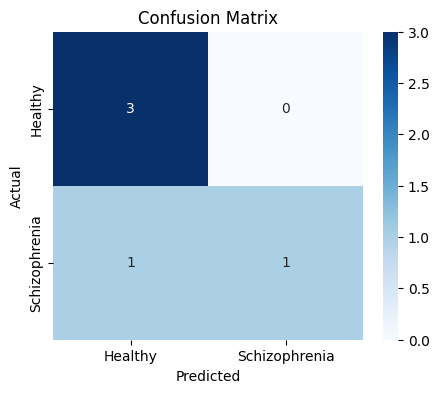

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Healthy", "Schizophrenia"],
            yticklabels=["Healthy", "Schizophrenia"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

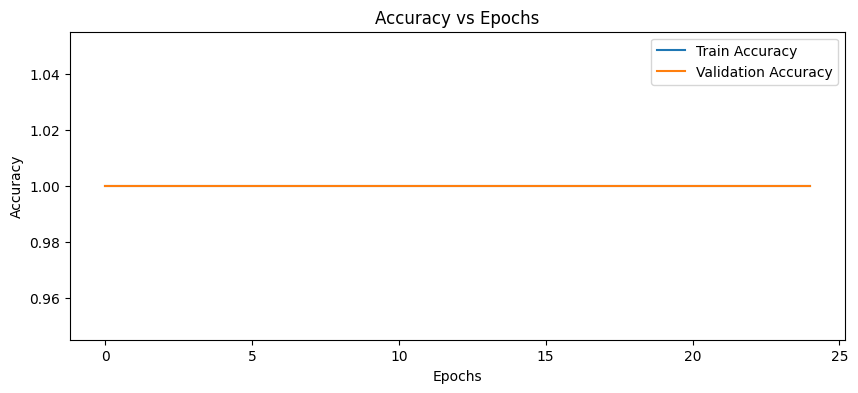

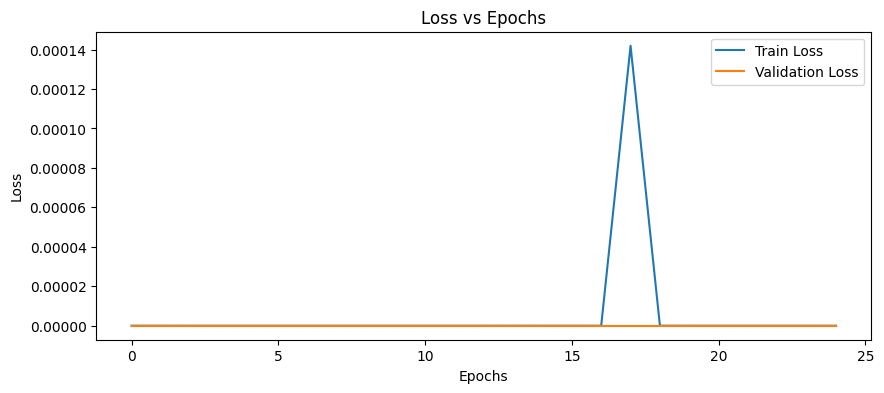

In [29]:
# Accuracy Plot
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss Plot
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

**Conclusion and Result Visulaization**

**Declaration**

I, Tanashree Koshti, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines. The code is uploaded on my GitHub repository account, and the repository link is provided below:

GitHub Repository Link: [Insert GitHub Link]

Signature: Tanashree R. Koshti

**Submission Checklist**

✔ Research paper details and summary

✔ Code file (Python Notebook or Script)

✔ Dataset or link to the dataset

✔ Visualizations (if applicable)

✔ Screenshots of model performance metrics

✔ Readme File

✔ Comparison with research paper results